In [1]:
#task--1
import sympy as sp
#sympy is used to calculate derivative better and give answer in expression
x = sp.Symbol('x')
expr = x**2 + 2*x + 1

deri=(sp.diff(expr, x)) 
print(deri)# derivative

2*x + 2


In [4]:
import sympy as sp

x = sp.Symbol('x')
expr = x**2 + 2*x + 1

deri = sp.diff(expr, x)

# store slopes in variables
slope_0 = deri.subs(x, 0)
slope_5 = deri.subs(x, 5)
slope_10 = deri.subs(x, 10)

print("Slope at 0:", slope_0)
print("Slope at 5:", slope_5)
print("Slope at 10:", slope_10)

Slope at 0: 2
Slope at 5: 12
Slope at 10: 22


This is exactly what happens in ML training:

derivative = gradient
slope = tells direction of change
large slope → big weight update
small slope → slow learning

👉 points show:

early stage (0) → small update
later stage (10) → very aggressive change

Big slope → fast learning
Small slope → slow learning
Zero slope → no learning (optimum reached)

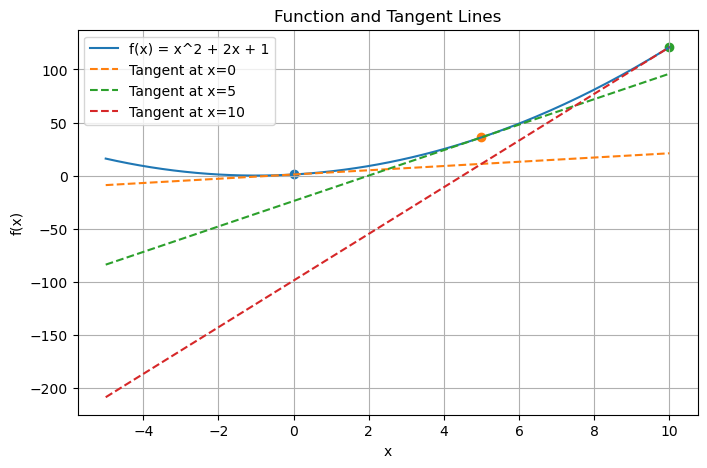

In [6]:
import numpy as np
import sympy as sp
import matplotlib.pyplot as plt

# function
def f(x):
    return x**2 + 2*x + 1

# x range for curve
x_vals = np.linspace(-5, 10, 200)
y_vals = f(x_vals)

# derivative using sympy
x = sp.Symbol('x')
expr = x**2 + 2*x + 1
deri = sp.diff(expr, x)

# points
points = [0, 5, 10]

plt.figure(figsize=(8,5))

# plot original curve
plt.plot(x_vals, y_vals, label="f(x) = x^2 + 2x + 1")

# plot tangent lines
for p in points:
    slope = deri.subs(x, p)
    y_p = f(p)
    
    tangent = slope*(x_vals - p) + y_p
    plt.plot(x_vals, tangent, linestyle="--", label=f"Tangent at x={p}")

# highlight points
for p in points:
    plt.scatter(p, f(p))

plt.legend()
plt.grid()
plt.title("Function and Tangent Lines")
plt.xlabel("x")
plt.ylabel("f(x)")
plt.show()

In [7]:
#task--2------******
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
#defining loss function
def loss(theta):
    return (theta - 3.5)**2 + 1
#define gradient function
def gradient(theta):
    return 2 * (theta - 3.5)


In [8]:
def gradient_descent(theta_start, learning_rate, iterations):
    
    theta = theta_start
    history = []
    
    for i in range(iterations):
        
        grad = gradient(theta)
        current_loss = loss(theta)
        
        history.append([
            i,
            theta,
            current_loss,
            grad
        ])
        
        theta = theta - learning_rate * grad
        
    return pd.DataFrame(
        history,
        columns=["Iteration", "Theta", "Loss", "Gradient"]
    )

In [9]:
np.random.seed(42)

theta_start = np.random.uniform(-5, 10)

print("Starting Theta:", theta_start)

Starting Theta: 0.6181017827104371


In [10]:
low_lr = gradient_descent(
    theta_start=theta_start,
    learning_rate=0.05,
    iterations=15
)

print(low_lr)

    Iteration     Theta      Loss  Gradient
0           0  0.618102  9.305337 -5.763796
1           1  0.906292  7.727323 -5.187417
2           2  1.165662  6.449132 -4.668675
3           3  1.399096  5.413797 -4.201808
4           4  1.609187  4.575175 -3.781627
5           5  1.798268  3.895892 -3.403464
6           6  1.968441  3.345673 -3.063118
7           7  2.121597  2.899995 -2.756806
8           8  2.259437  2.538996 -2.481125
9           9  2.383494  2.246587 -2.233013
10         10  2.495144  2.009735 -2.009712
11         11  2.595630  1.817885 -1.808740
12         12  2.686067  1.662487 -1.627866
13         13  2.767460  1.536615 -1.465080
14         14  2.840714  1.434658 -1.318572


In [11]:
high_lr = gradient_descent(
    theta_start=theta_start,
    learning_rate=0.5,
    iterations=15
)

print(high_lr)

    Iteration     Theta      Loss  Gradient
0           0  0.618102  9.305337 -5.763796
1           1  3.500000  1.000000  0.000000
2           2  3.500000  1.000000  0.000000
3           3  3.500000  1.000000  0.000000
4           4  3.500000  1.000000  0.000000
5           5  3.500000  1.000000  0.000000
6           6  3.500000  1.000000  0.000000
7           7  3.500000  1.000000  0.000000
8           8  3.500000  1.000000  0.000000
9           9  3.500000  1.000000  0.000000
10         10  3.500000  1.000000  0.000000
11         11  3.500000  1.000000  0.000000
12         12  3.500000  1.000000  0.000000
13         13  3.500000  1.000000  0.000000
14         14  3.500000  1.000000  0.000000


In [12]:
print("LOW LEARNING RATE")
display(low_lr)

print("HIGH LEARNING RATE")
display(high_lr)

LOW LEARNING RATE


,Iteration,Theta,Loss,Gradient
0,0,0.618102,9.305337,-5.763796
1,1,0.906292,7.727323,-5.187417
2,2,1.165662,6.449132,-4.668675
3,3,1.399096,5.413797,-4.201808
4,4,1.609187,4.575175,-3.781627
5,5,1.798268,3.895892,-3.403464
6,6,1.968441,3.345673,-3.063118
7,7,2.121597,2.899995,-2.756806
8,8,2.259437,2.538996,-2.481125
9,9,2.383494,2.246587,-2.233013


HIGH LEARNING RATE


,Iteration,Theta,Loss,Gradient
0,0,0.618102,9.305337,-5.763796
1,1,3.500000,1.000000,0.000000
2,2,3.500000,1.000000,0.000000
3,3,3.500000,1.000000,0.000000
4,4,3.500000,1.000000,0.000000
5,5,3.500000,1.000000,0.000000
6,6,3.500000,1.000000,0.000000
7,7,3.500000,1.000000,0.000000
8,8,3.500000,1.000000,0.000000
9,9,3.500000,1.000000,0.000000


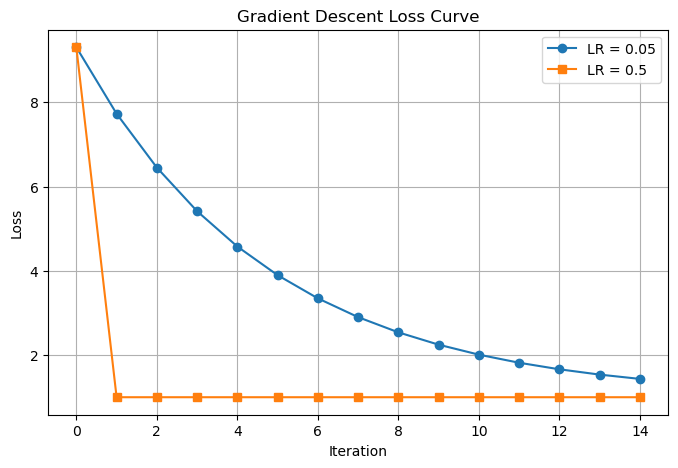

In [13]:
plt.figure(figsize=(8,5))

plt.plot(
    low_lr["Iteration"],
    low_lr["Loss"],
    marker='o',
    label='LR = 0.05'
)

plt.plot(
    high_lr["Iteration"],
    high_lr["Loss"],
    marker='s',
    label='LR = 0.5'
)

plt.title("Gradient Descent Loss Curve")
plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.legend()
plt.grid()

plt.show()

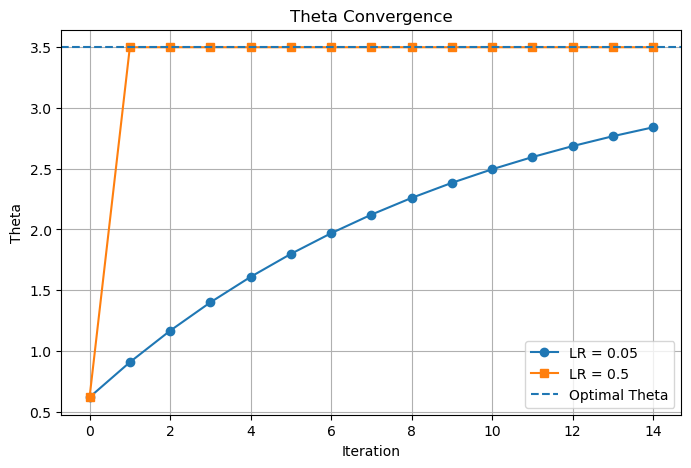

In [14]:
plt.figure(figsize=(8,5))

plt.plot(
    low_lr["Iteration"],
    low_lr["Theta"],
    marker='o',
    label='LR = 0.05'
)

plt.plot(
    high_lr["Iteration"],
    high_lr["Theta"],
    marker='s',
    label='LR = 0.5'
)

plt.axhline(
    y=3.5,
    linestyle='--',
    label='Optimal Theta'
)

plt.title("Theta Convergence")
plt.xlabel("Iteration")
plt.ylabel("Theta")

plt.legend()
plt.grid()

plt.show()

Expected Observation

The minimum of the loss function occurs at:
θ=3.5

The gradient descent algorithm should move θ toward 3.5.

Low LR → gradual movement toward 3.5
High LR → rapid movement toward 3.5
Loss decreases each iteration until it approaches 1 (the minimum possible loss)

In [15]:
#########################task----3-------#############################

np.random.seed(42)

uniform_data = np.random.uniform(
    low=0,
    high=10,
    size=1000
)

normal_data = np.random.normal(
    loc=5,
    scale=2,
    size=1000
)

In [16]:
uniform_mean = np.mean(uniform_data)
uniform_std = np.std(uniform_data)

normal_mean = np.mean(normal_data)
normal_std = np.std(normal_data)

print("Uniform Distribution")
print("Mean:", round(uniform_mean, 2))
print("Standard Deviation:", round(uniform_std, 2))

print("\nNormal Distribution")
print("Mean:", round(normal_mean, 2))
print("Standard Deviation:", round(normal_std, 2))

Uniform Distribution
Mean: 4.9
Standard Deviation: 2.92

Normal Distribution
Mean: 5.2
Standard Deviation: 1.98


In [17]:
summary = pd.DataFrame({
    "Distribution": ["Uniform", "Normal"],
    "Mean": [uniform_mean, normal_mean],
    "Std Dev": [uniform_std, normal_std]
})

summary

,Distribution,Mean,Std Dev
0,Uniform,4.902566,2.919913
1,Normal,5.197792,1.976877


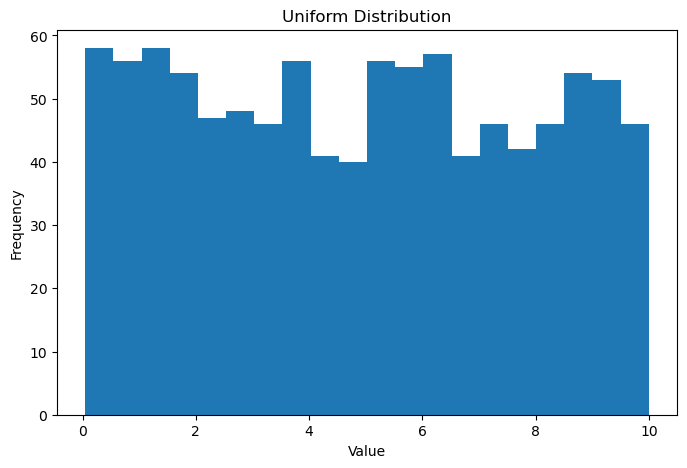

In [18]:
plt.figure(figsize=(8,5))

plt.hist(uniform_data, bins=20)

plt.title("Uniform Distribution")
plt.xlabel("Value")
plt.ylabel("Frequency")

plt.show()

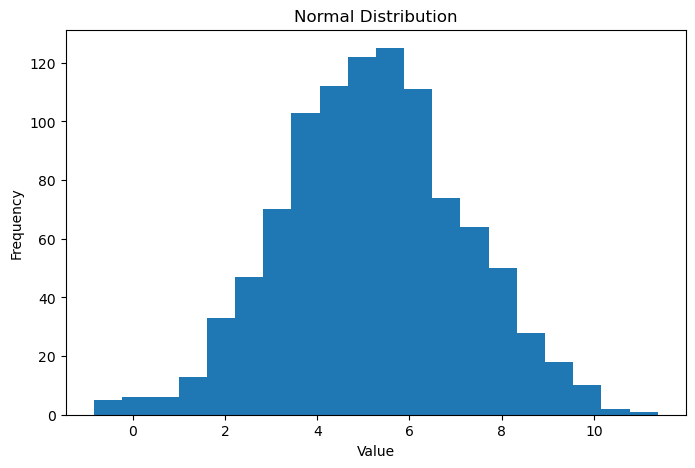

In [19]:
plt.figure(figsize=(8,5))

plt.hist(normal_data, bins=20)

plt.title("Normal Distribution")
plt.xlabel("Value")
plt.ylabel("Frequency")

plt.show()

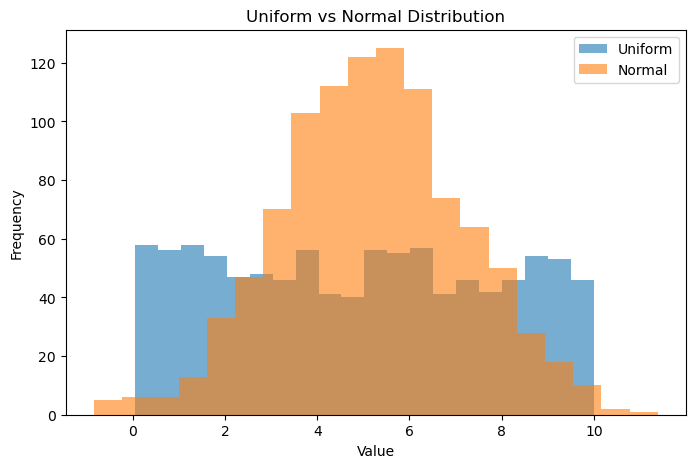

In [20]:
plt.figure(figsize=(8,5))

plt.hist(
    uniform_data,
    bins=20,
    alpha=0.6,
    label="Uniform"
)

plt.hist(
    normal_data,
    bins=20,
    alpha=0.6,
    label="Normal"
)

plt.legend()

plt.title("Uniform vs Normal Distribution")
plt.xlabel("Value")
plt.ylabel("Frequency")

plt.show()

Report Explanation

Uniform Distribution
Every value between 0 and 10 is almost equally likely.
Histogram appears flat or rectangular.
Data is spread evenly across the range.
Mean is near the center (around 5).
Expectation Interpretation

Expected value ≈ mean.

If we repeatedly sample numbers from this distribution, the average value will approach about 5.

Normal Distribution
Most values occur near the mean.
Few values occur far from the mean.
Histogram forms a bell-shaped curve.
Mean is around 5.
Expectation Interpretation

Expected value ≈ mean.

If we repeatedly sample numbers, the average value tends toward about 5, with most samples clustering around that value.

In [21]:
##########task-4-----+##################
import pandas as pd 
df=pd.read_csv("housing.csv")
df

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY
...,...,...,...,...,...,...,...,...,...,...
20635,-121.09,39.48,25.0,1665.0,374.0,845.0,330.0,1.5603,78100.0,INLAND
20636,-121.21,39.49,18.0,697.0,150.0,356.0,114.0,2.5568,77100.0,INLAND
20637,-121.22,39.43,17.0,2254.0,485.0,1007.0,433.0,1.7000,92300.0,INLAND
20638,-121.32,39.43,18.0,1860.0,409.0,741.0,349.0,1.8672,84700.0,INLAND


In [22]:
df.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


In [23]:
df.columns

Index(['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income',
       'median_house_value', 'ocean_proximity'],
      dtype='object')

In [26]:
print("Shape:", df.shape)
print() 
df.info()

Shape: (20640, 10)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


In [27]:
df.isnull().sum()

longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64

In [28]:
df.duplicated().sum()

np.int64(0)

In [29]:
#we will fill the null values with median 
df["total_bedrooms"] = df["total_bedrooms"].fillna(
    df["total_bedrooms"].median()
)

In [30]:
df.isnull().sum()

longitude             0
latitude              0
housing_median_age    0
total_rooms           0
total_bedrooms        0
population            0
households            0
median_income         0
median_house_value    0
ocean_proximity       0
dtype: int64

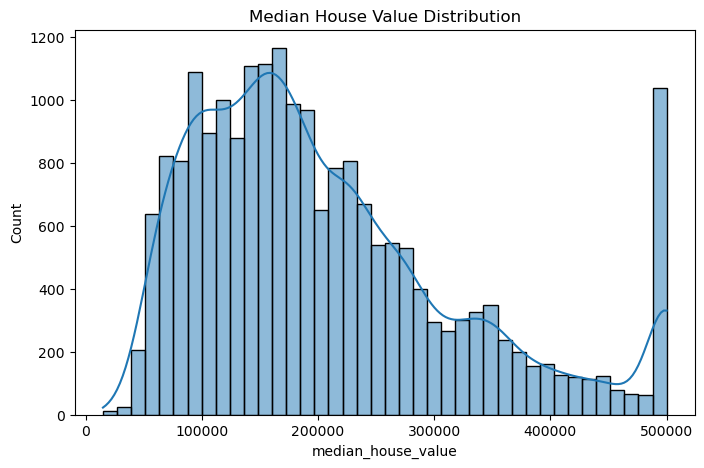

In [32]:
#now there is no null and duplicate values in the data 
#target variable distribution
import seaborn as sns 
plt.figure(figsize=(8,5))

sns.histplot(
    df["median_house_value"],
    bins=40,
    kde=True
)

plt.title("Median House Value Distribution")
plt.show()

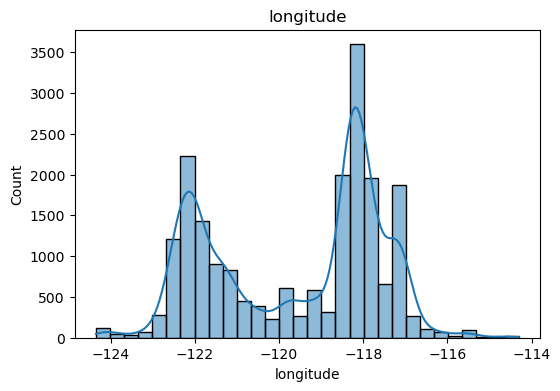

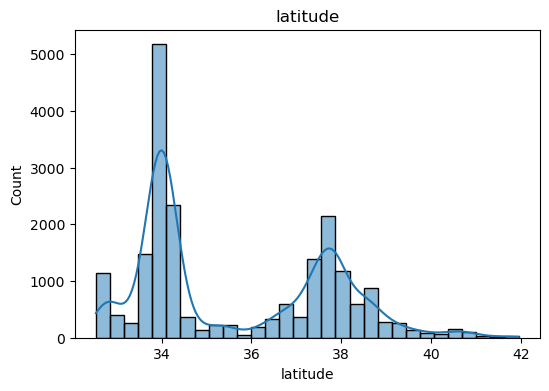

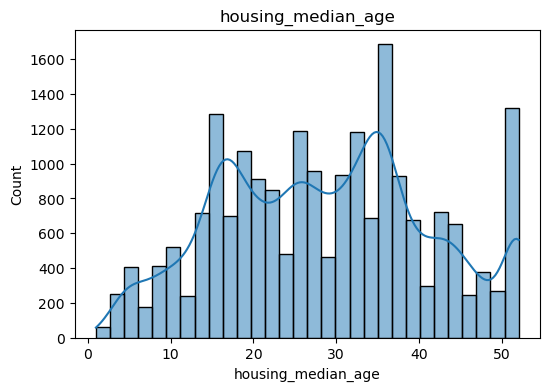

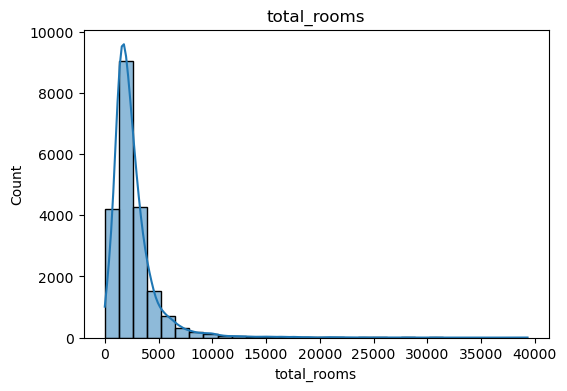

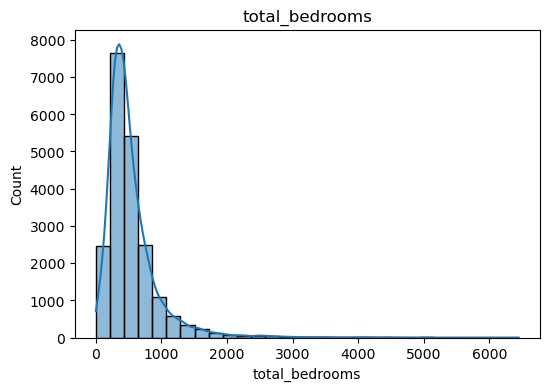

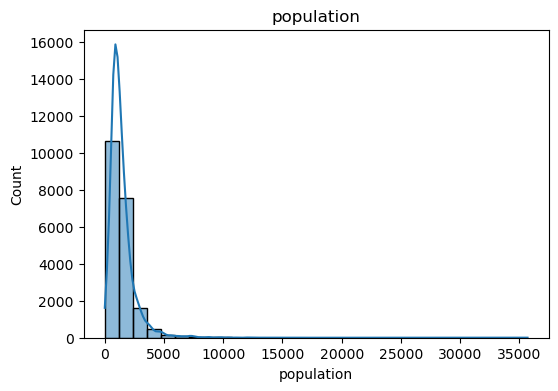

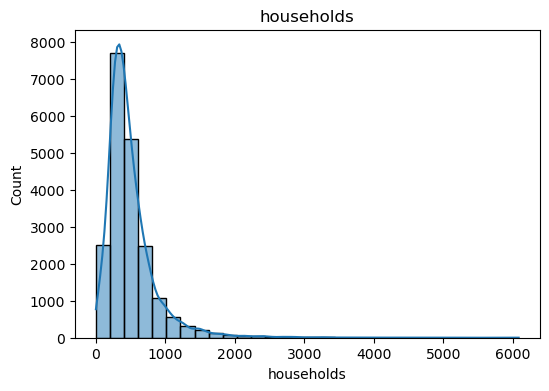

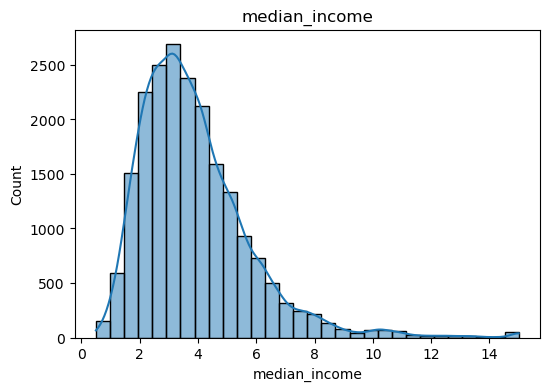

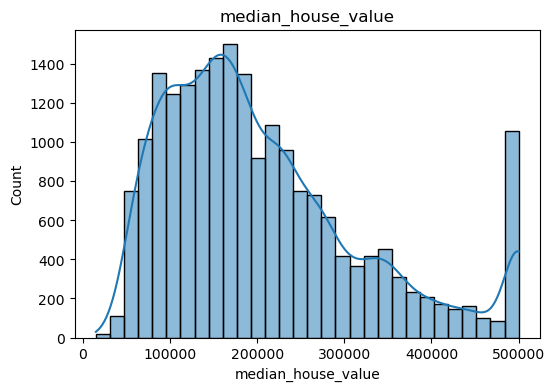

In [33]:
#numeric feature extraction 
num_cols = df.select_dtypes(
    include=np.number
).columns

for col in num_cols:
    
    plt.figure(figsize=(6,4))
    
    sns.histplot(
        df[col],
        bins=30,
        kde=True
    )
    
    plt.title(col)
    
    plt.show()

In [34]:
df["ocean_proximity"].value_counts()

ocean_proximity
<1H OCEAN     9136
INLAND        6551
NEAR OCEAN    2658
NEAR BAY      2290
ISLAND           5
Name: count, dtype: int64

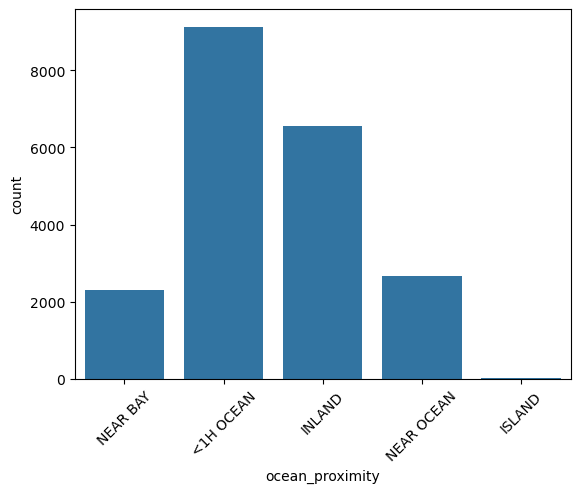

In [35]:
sns.countplot(
    data=df,
    x="ocean_proximity"
)

plt.xticks(rotation=45)
plt.show()

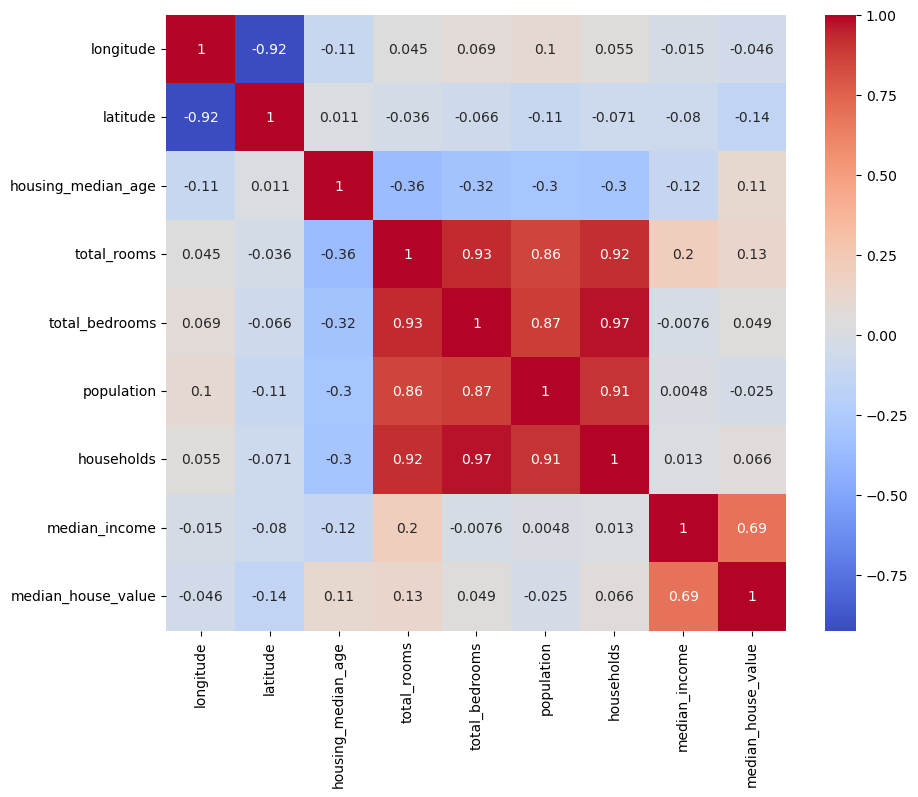

In [36]:
corr = df.corr(
    numeric_only=True
)

plt.figure(figsize=(10,8))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm"
)

plt.show()

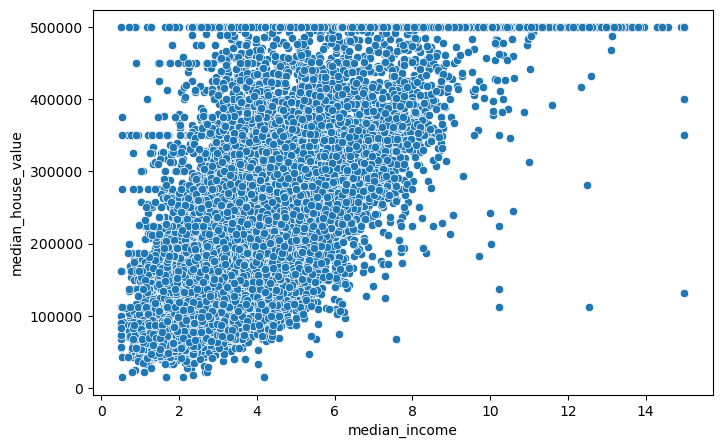

In [37]:
#inclome vs house prce 
plt.figure(figsize=(8,5))

sns.scatterplot(
    x="median_income",
    y="median_house_value",
    data=df
)

plt.show()

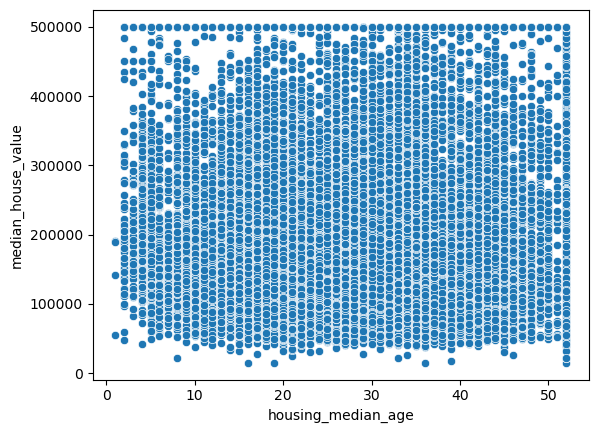

In [38]:
#hpuse age vs house price 
sns.scatterplot(
    x="housing_median_age",
    y="median_house_value",
    data=df
)

plt.show()

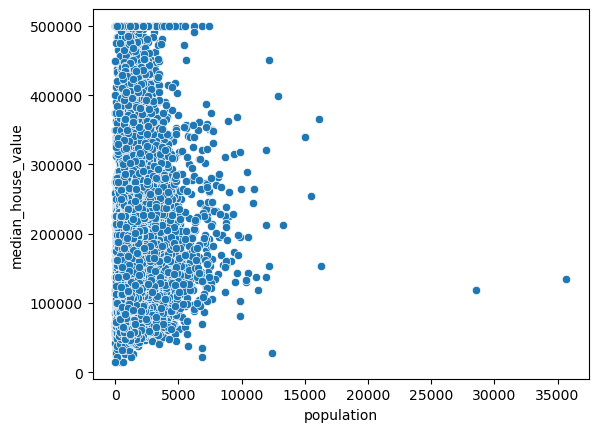

In [39]:
sns.scatterplot(
    x="population",
    y="median_house_value",
    data=df
)

plt.show()

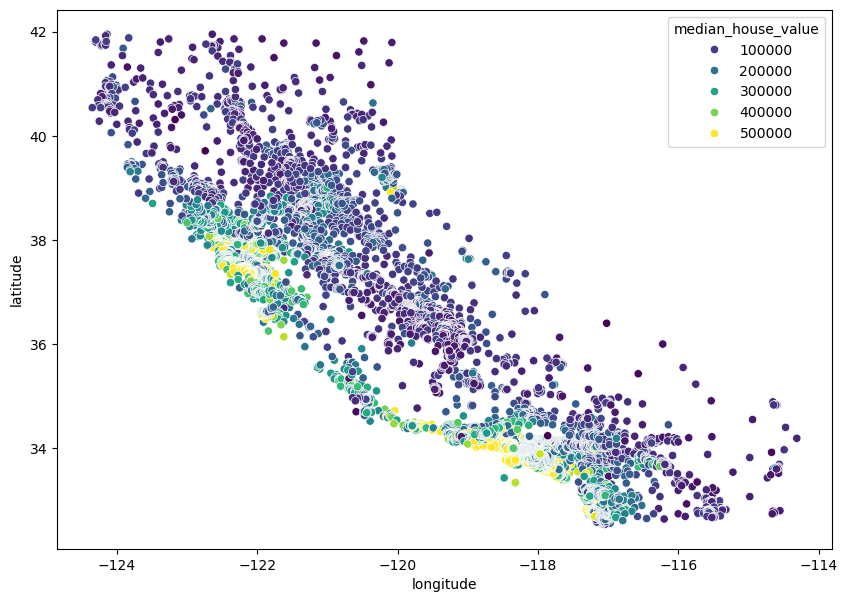

In [40]:
#california house price 
plt.figure(figsize=(10,7))

sns.scatterplot(
    x="longitude",
    y="latitude",
    hue="median_house_value",
    data=df,
    palette="viridis"
)

plt.show()

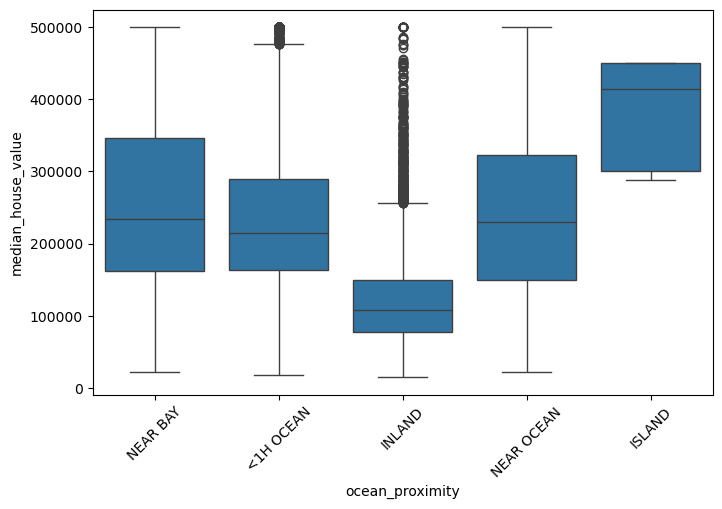

In [41]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x="ocean_proximity",
    y="median_house_value",
    data=df
)

plt.xticks(rotation=45)
plt.show()

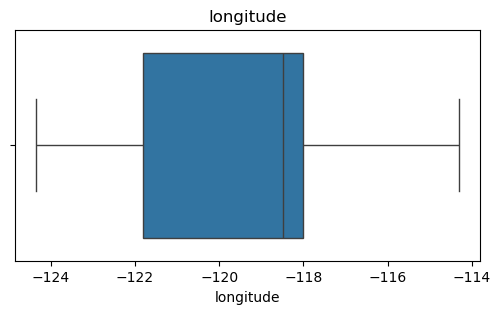

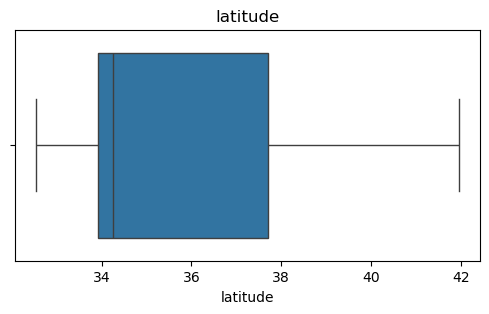

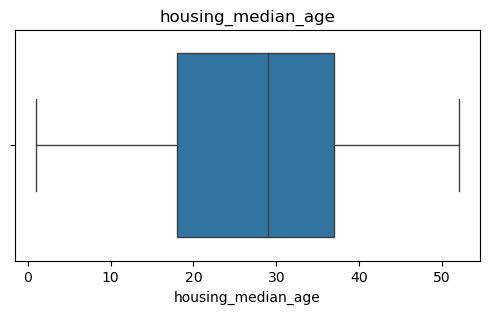

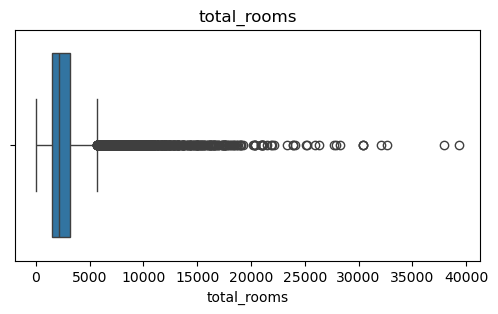

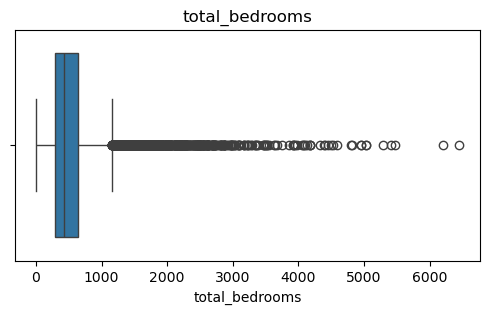

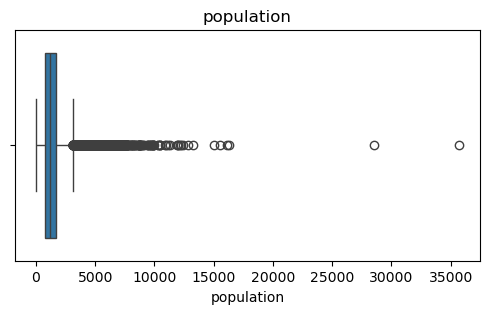

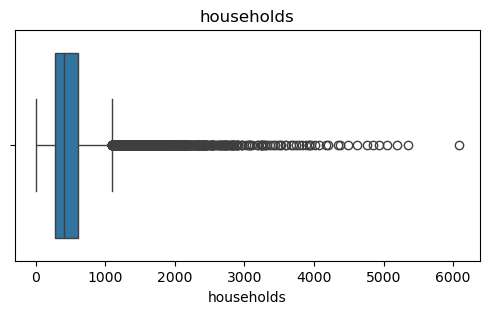

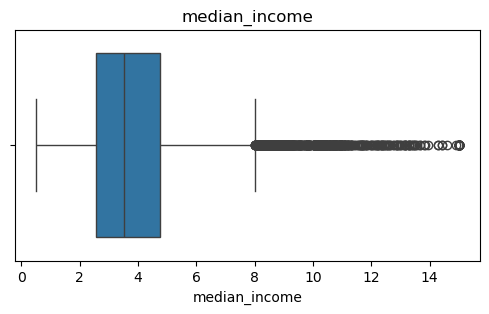

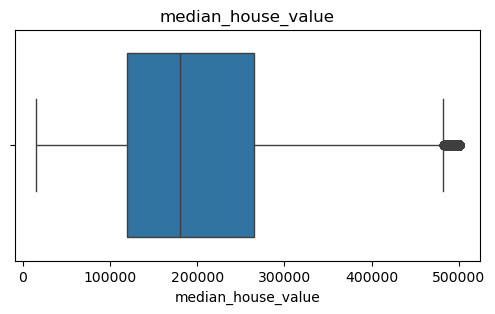

In [42]:
for col in num_cols:
    
    plt.figure(figsize=(6,3))
    
    sns.boxplot(
        x=df[col]
    )
    
    plt.title(col)
    
    plt.show()

In [43]:
df["rooms_per_household"] = (
    df["total_rooms"] /
    df["households"]
)

df["bedrooms_per_room"] = (
    df["total_bedrooms"] /
    df["total_rooms"]
)

df["population_per_household"] = (
    df["population"] /
    df["households"]
)

In [44]:
df

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity,rooms_per_household,bedrooms_per_room,population_per_household
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY,6.984127,0.146591,2.555556
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY,6.238137,0.155797,2.109842
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY,8.288136,0.129516,2.802260
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY,5.817352,0.184458,2.547945
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY,6.281853,0.172096,2.181467
...,...,...,...,...,...,...,...,...,...,...,...,...,...
20635,-121.09,39.48,25.0,1665.0,374.0,845.0,330.0,1.5603,78100.0,INLAND,5.045455,0.224625,2.560606
20636,-121.21,39.49,18.0,697.0,150.0,356.0,114.0,2.5568,77100.0,INLAND,6.114035,0.215208,3.122807
20637,-121.22,39.43,17.0,2254.0,485.0,1007.0,433.0,1.7000,92300.0,INLAND,5.205543,0.215173,2.325635
20638,-121.32,39.43,18.0,1860.0,409.0,741.0,349.0,1.8672,84700.0,INLAND,5.329513,0.219892,2.123209


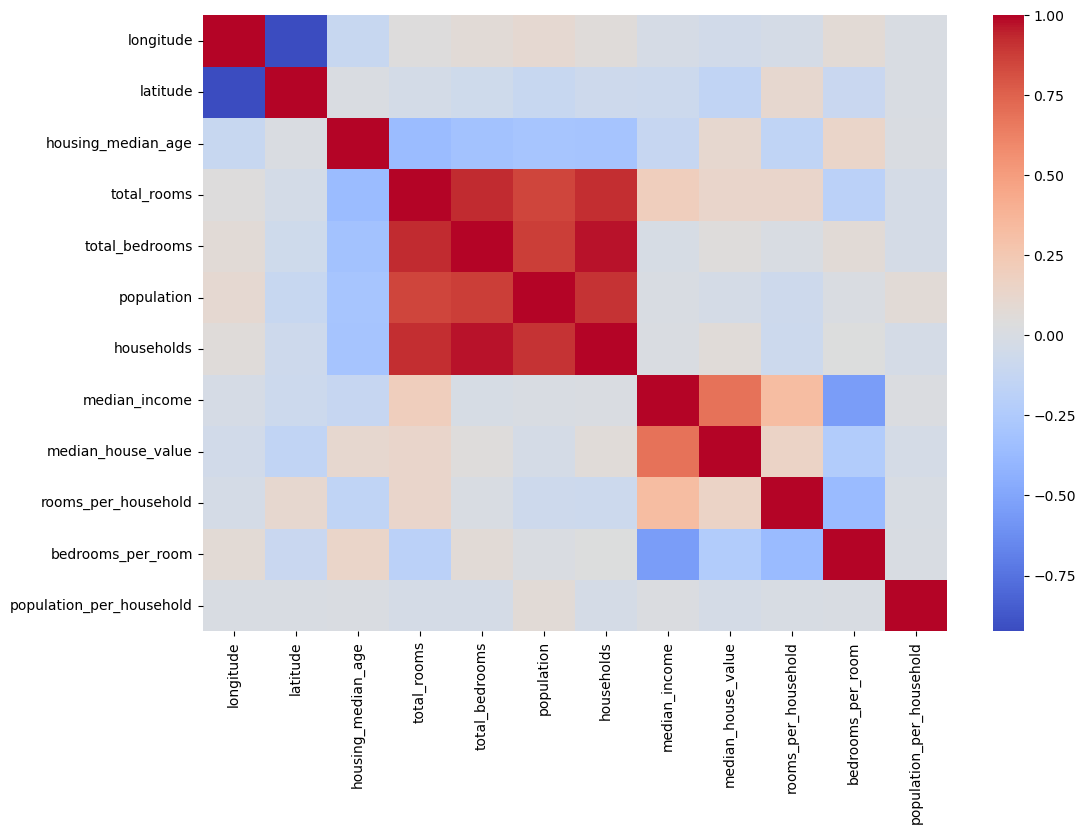

In [45]:
corr = df.corr(
    numeric_only=True
)

plt.figure(figsize=(12,8))

sns.heatmap(
    corr,
    cmap="coolwarm"
)

plt.show()

Key Findings
Dataset contains approximately 20,640 records and 10 features.
total_bedrooms has missing values requiring imputation.
median_income is the strongest predictor of house prices.
Houses closer to the ocean generally have higher prices.
House values are right-skewed.
Population-related features contain significant outliers.
Location (latitude, longitude) has a strong impact on house value.

Engineered features such as:

rooms_per_household
bedrooms_per_room
population_per_household

can improve model performance.